## 1. Purpose

Workbook for the two gradient-descent-trained models (DNN and PINN, no-environment
feature set) — the sklearn/Chapman-Richards baselines already have their own results
notebook (`baseline_results.ipynb`) and this one deliberately doesn't duplicate that,
since none of the four baselines use gradient descent and so have no loss curves to
look at.

This notebook only *reads* what's already saved under `outputs/` — it never trains or
evaluates anything itself. See section 2 below for exactly which scripts to run first.

Covers **both split types** DNN/PINN can now run under:
- `temporal` — train on the earliest years, validate on 2021, test on 2023
- `spatial_block` — train/val/test are whole held-out forestry compartments

Four things this notebook is for:
1. Plotting training/validation loss curves for whichever runs exist.
2. A results table comparing DNN/PINN against the matching baseline numbers for the
   *same* split type, so a new run's metrics are always read next to the numbers
   they're actually being compared against.
3. A running record of what's been tried and what to try next.
4. Comparing the two split types against each other, once both exist.

In [1]:
# Purpose: Make the models/ package importable from this notebook.
# Key logic: Walk upward from the current folder until a folder containing
# both README.md and data/ is found — that is the project root.

import sys
from pathlib import Path

notebook_directory = Path.cwd().resolve()
project_root = next(
    folder for folder in [notebook_directory, *notebook_directory.parents]
    if (folder / "README.md").exists() and (folder / "data").exists()
)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
import json

import matplotlib.pyplot as plt
import pandas as pd

from models.common.plotting import plot_loss_curve
from models.common.saving import model_output_dir

pd.set_option("display.max_columns", 50)

COHORTS = ["4survey", "6survey"]
NEURAL_MODELS = ["dnn_noenv", "pinn_noenv"]
BASELINE_MODELS = ["chapman_richards", "average_by_age", "linear_baseline", "rf_baseline"]

# DNN/PINN never run plot_level (that was only ever the baselines' original
# sanity check), so only these two split types apply to them.
SPLIT_TYPES = ["temporal", "spatial_block"]

## 2. Which files to run, to (re)compile these results

1. **Push cleaned data to the cluster** (`data/processed/` is gitignored, never
   travels via git): `rsync` `data/processed/master/*.parquet` to the cluster, then
   there run `python -m data_processing.export_model_tables` to regenerate
   `data/processed/current_state/` on that machine.
2. **Fit, on the cluster (GPU)**:
   `python -m models.dnn_noenv.run_dnn_noenv --cohort <4survey|6survey> --split-type <temporal|spatial_block> --max-epochs 500`
   and the same for `models.pinn_noenv.run_pinn_noenv`. Omit `--cohort` to run both.
   `--split-type` defaults to `temporal` if omitted. This is the FIT-only step — it
   never touches the test split. Saves checkpoints, scalers, `training_history.csv`,
   `run_metadata.json` under `outputs/<split_type>/<model>/<cohort>/` (`temporal` and
   `spatial_block` are always prefixed; there is no unprefixed default for DNN/PINN,
   unlike the baselines, since DNN/PINN never run `plot_level`).
3. **Pull results back**: `rsync` `outputs/temporal/`, `outputs/spatial_block/`, and
   `outputs/run_logs/` from the cluster down to the laptop.
4. **Evaluate, locally (cheap, CPU)**:
   `python -m models.dnn_noenv.evaluate_dnn_noenv --split-type <temporal|spatial_block>`
   and the same for `models.pinn_noenv.evaluate_pinn_noenv` (omit `--cohort` for
   both). This is what actually writes the real `metrics.json`/`predictions.csv` this
   notebook reads below.

Before trusting a result read below as real: check `run_metadata.json`'s
`max_epochs` for that run wasn't a quick sanity check (see
`documentation/progress_notes.md`, "Checking a run is good, not just present").

## 3. Training / validation loss curves

One panel per model per cohort, one figure per split type. `train_loss`/`val_loss`
are always plotted; `data_loss`/`physics_loss`/`trajectory_loss` are added
automatically for the PINN (see `models/common/plotting.py::plot_loss_curve`). The
dotted vertical line marks the best epoch — the one `load_best_model()` actually
loads, not necessarily the last epoch trained.

A panel is left blank with a note if that `(model, cohort, split_type)` combination
hasn't been run yet.

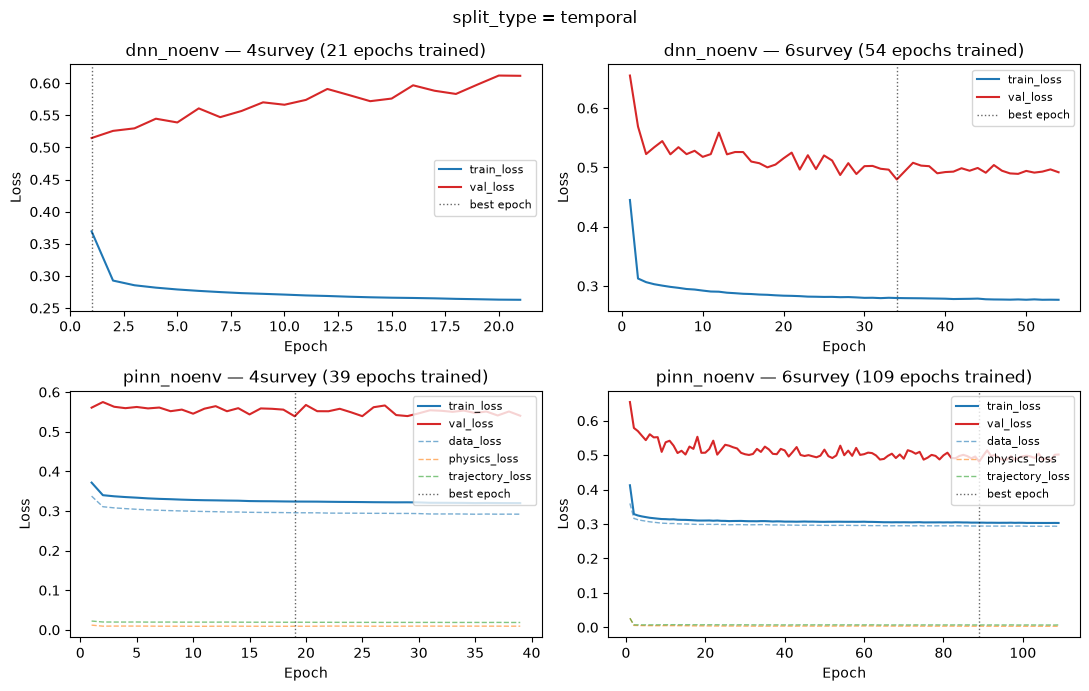

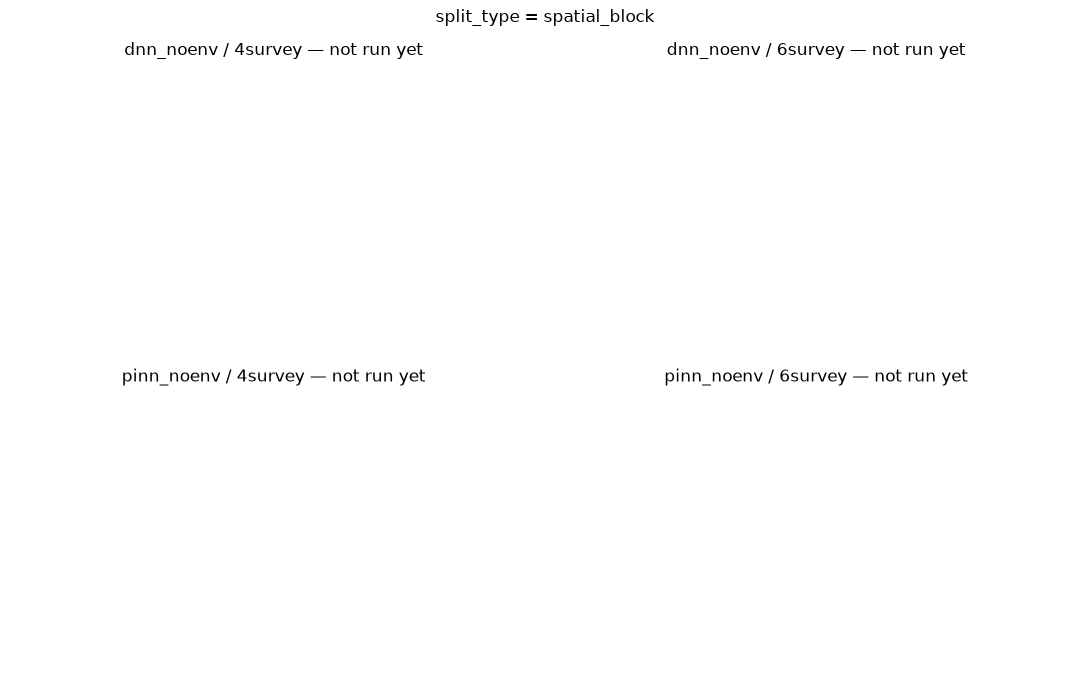

In [3]:
for split_type in SPLIT_TYPES:
    fig, axes = plt.subplots(len(NEURAL_MODELS), len(COHORTS), figsize=(11, 7))
    fig.suptitle(f"split_type = {split_type}")

    for row, model_name in enumerate(NEURAL_MODELS):
        for col, cohort in enumerate(COHORTS):
            ax = axes[row, col]
            history_path = model_output_dir(model_name, cohort, split_type=split_type) / "training_history.csv"
            if not history_path.exists():
                ax.set_title(f"{model_name} / {cohort} — not run yet")
                ax.axis("off")
                continue
            history_df = pd.read_csv(history_path)
            plot_loss_curve(history_df, ax=ax)
            ax.set_title(f"{model_name} — {cohort} ({len(history_df)} epochs trained)")

    fig.tight_layout()
    plt.show()

## 4. Test-set metrics: DNN/PINN vs. the matching-split-type baselines

Reads whatever `metrics.json` currently exists for each model under each split type
— real numbers once the full-length runs have been evaluated, sanity-check numbers
until then (check `run_metadata.json`'s `max_epochs` if unsure which one you're
looking at). Baselines are only compared within the *same* split type, since a
`temporal` DNN result isn't a fair comparison against a `plot_level` or
`spatial_block` baseline number.

In [4]:
def load_metrics(path):
    if not path.exists():
        return None
    with open(path) as f:
        return json.load(f)


rows = []
for split_type in SPLIT_TYPES:
    for cohort in COHORTS:
        for model_name in BASELINE_MODELS + NEURAL_MODELS:
            metrics = load_metrics(model_output_dir(model_name, cohort, split_type=split_type) / "metrics.json")
            if metrics is not None:
                rows.append({"split_type": split_type, "cohort": cohort, "model": model_name, **metrics})

metrics_table = pd.DataFrame(rows)[["split_type", "cohort", "model", "mae", "rmse", "r2", "bias", "accuracy_pct"]]
metrics_table.sort_values(["split_type", "cohort", "rmse"])

,split_type,cohort,model,mae,rmse,r2,bias,accuracy_pct
14,spatial_block,4survey,linear_baseline,4.611554,5.816721,0.474833,-0.127076,75.485714
15,spatial_block,4survey,rf_baseline,4.534183,5.988427,0.443370,0.064402,76.444318
12,spatial_block,4survey,chapman_richards,4.867781,6.107296,0.421053,1.834744,74.990029
13,spatial_block,4survey,average_by_age,5.113634,6.347579,0.374601,2.171900,74.015856
17,spatial_block,6survey,average_by_age,2.686161,3.891533,0.708337,-0.226866,84.838055
16,spatial_block,6survey,chapman_richards,2.858532,3.966825,0.696941,0.040132,84.169889
18,spatial_block,6survey,linear_baseline,3.148344,4.086458,0.678386,-0.342050,81.690652
19,spatial_block,6survey,rf_baseline,3.266831,4.604027,0.591759,-0.997472,80.529402
4,temporal,4survey,dnn_noenv,4.607954,5.864798,0.452423,0.318159,77.060348
5,temporal,4survey,pinn_noenv,4.860543,6.074789,0.412509,0.571382,75.364232


## 5. Experiments run so far (DNN/PINN specifically)

Full detail and the reasoning chain live in `documentation/experiment_log.md`'s
Findings log — this section is a short pointer, not a duplicate.

- **Baselines under `temporal_split`** (2026-07-15): far larger degradation than under
  `spatial_block_split` — up to +141.7% RMSE for some models, `average_by_age`'s R²
  went negative on 6survey. Chapman-Richards (the physically-constrained model)
  degraded the *least* — the direct empirical motivation for the PINN.
- **First real DNN/PINN run** (2026-07-16, `temporal_split`, `--max-epochs 500`):
  both models beat every temporal-split baseline on both cohorts, but the physics
  constraint doesn't win outright — DNN edges out PINN on 4survey, PINN edges out DNN
  on 6survey. Looking at the loss curves themselves (section 3) matters here: DNN's
  4survey run has `best_epoch=1` (a textbook overfitting climb — `val_loss` rises
  almost monotonically after epoch 1 while `train_loss` keeps falling), so its
  reported RMSE is closer to an untrained model's number than a converged one. PINN's
  4survey `val_loss`, on the exact same narrow 2-year training set, stays flat
  instead of climbing — a real, citable regularization effect from the physics terms,
  independent of whichever model wins on final RMSE.
- **`spatial_block_split` wired into DNN/PINN** (2026-07-16): previously only the
  four sklearn/CR baselines could run under `spatial_block_split` — this is the split
  that actually tests the dissertation's central spatial/environmental-attribution
  question, more so than `temporal_split`. Not yet run at full length as of writing —
  see section 3 for whatever's there now.
- **Not yet run**: full-length (`--max-epochs 500`) DNN/PINN training under
  `spatial_block_split`. This is the next real result to get, and the one to
  hyperparameter-tune against before moving back to `temporal_split` for comparison.

## 6. Ideas for parameter tuning (once a real run exists)

Concrete things to check in the loss curve — not conclusions yet, just what to look
for and what to try if a problem shows up.

| What to check in the loss curve | If you see this... | ...try this |
|---|---|---|
| `val_loss` vs `train_loss` gap | `val_loss` plateaus or rises early while `train_loss` keeps falling (overfitting) — this is exactly what happened to DNN/4survey under `temporal_split` | increase `L1_COEFFICIENT`, add dropout, or reduce `NoEnvNetwork`'s width/depth (`models/common/torch_model.py`) |
| `val_loss` shape | never really improves, both losses flat from the start (underfitting / stuck) | raise `LEARNING_RATE`, check `LR_SCHEDULER_PATIENCE`/`LR_SCHEDULER_FACTOR` aren't shrinking it too fast, or widen the network |
| best epoch vs. total trained | best epoch is very early and training runs long past it without improving | may resolve itself with more training years / more spatial diversity in train (as `spatial_block_split` gives, vs. `temporal_split`'s narrow 2-year 4survey training set); if not, the learning rate may be too high early on |
| PINN's `physics_loss`/`trajectory_loss` vs `data_loss` | one term numerically dominates the combined `train_loss` | re-tune `PHYSICS_WEIGHT`/`TRAJECTORY_WEIGHT` (`models/pinn_noenv/pinn_noenv.py`) so no single term swamps the others |
| PINN's `physics_loss`/`trajectory_loss` going to ~0 immediately | the physics terms aren't actually constraining anything (trivially satisfied) | check they're computed against the *unscaled* CR curve correctly, and that `frozen_cr_params` in `run_metadata.json` are sensible, not degenerate |
| DNN vs PINN, same split type | PINN's test RMSE isn't better than the DNN's | not automatically a bug — under `temporal_split` this was already a genuine mixed result; check the loss *curves*, not just final RMSE, before concluding either way (see section 5) |
| Same model, `temporal` vs. `spatial_block` | very different loss-curve shape/stability between the two splits | expected to some degree -- `spatial_block`'s training set spans all four survey years for every train-plot, `temporal`'s 4survey training set is only two years, so more temporal diversity alone could explain a healthier curve, independent of the split type "being easier" |

Also planned (see `experiment_log.md`'s "Planned robustness checks" table, not yet
triggered): temporal split Design 2, and the PINN's Route B CR anchor.